In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
colors_p = plt.cm.tab20(np.linspace(0, 1, N))
colors_p[0], colors_p[5], colors_p[10], colors_p[2], colors_p[3], colors_p[1], colors_p[7] = colors_p[2].copy(), colors_p[3].copy(), colors_p[0].copy(), colors_p[5].copy(), colors_p[10].copy(), colors_p[7].copy(), colors_p[1].copy()
colors_p[6], colors_p[7] = colors_p[7].copy(), colors_p[6].copy()
colors_p[6], colors_p[1] = colors_p[1].copy(), colors_p[6].copy()

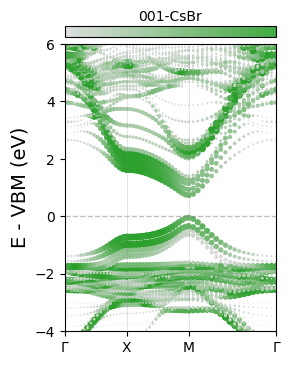

In [4]:
# ============================
# 1. LER PBAND_SUM.dat
# ============================
arquivo_bandas = "soc_bands/PBAND_SUM_SOC_001CsBr.dat"

bandas = {}
k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []

with open(arquivo_bandas, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("#K-Path") or linha.startswith("# NKPTS"):
            continue

        if linha.startswith("# Band-Index:"):
            # salva a banda anterior
            if k_vals and e_vals:
                bandas[band_index] = {
                    "k": np.array(k_vals),
                    "E": np.array(e_vals),
                    "s": np.array(s_vals),
                    "p": np.array(p_vals),
                    "d": np.array(d_vals),
                    "tot": np.array(tot_vals),
                }
                k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []
            band_index = int(linha.split()[-1])
            continue

        partes = linha.split()
        if len(partes) >= 6:
            k_vals.append(float(partes[0]))
            e_vals.append(float(partes[1]))
            s_vals.append(float(partes[2]))
            p_vals.append(float(partes[3]))
            d_vals.append(float(partes[4]))
            tot_vals.append(float(partes[5]))

# Salva a última banda
if k_vals and e_vals:
    bandas[band_index] = {
        "k": np.array(k_vals),
        "E": np.array(e_vals),
        "s": np.array(s_vals),
        "p": np.array(p_vals),
        "d": np.array(d_vals),
        "tot": np.array(tot_vals),
    }

# ============================
# 2. LER KLABELS
# ============================
arquivo_klabels = "KLABELS-001"

k_labels = []
k_positions = []

with open(arquivo_klabels, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("K-Label"):
            continue
        partes = linha.split()
        if len(partes) == 2:
            label, pos = partes
            k_labels.append(label.replace("GAMMA", "Γ"))
            k_positions.append(float(pos))

# ============================
# 3. ESCOLHER ORBITAL
# ============================
# pode ser "s", "p", "d" ou "tot"
orbital = "tot"

# ============================
# 4. PLOTAR
# ============================
plt.figure(figsize=(3,4))

import matplotlib.colors as mcolors

# Cores de início e fim
colors = ["gainsboro", colors_p[0]]

# Criar colormap contínuo azul→vermelho
cmap = mcolors.LinearSegmentedColormap.from_list("azul_vermelho", colors)

for b in bandas:
    data = bandas[b]
    k = data["k"]
    e = data["E"]
    w = data[orbital]

    # Normaliza o tamanho dos marcadores para visualização
    if np.max(w) > 0:
        sizes = 25 * (w / np.max(w))  # escala relativa
    else:
        sizes = np.zeros_like(w)

    plt.scatter(k, e, s=sizes, c=w, cmap=cmap, alpha=0.9, edgecolors="none")
    
#    if b == 178:
#        plt.plot(k, e, c="black", linewidth=1)
#    
#    if b == 180:
#        plt.plot(k, e, c="black", linewidth=1)

# Linhas verticais nos pontos de alta simetria
for pos in k_positions:
    plt.axvline(pos, color="gray", alpha=0.3, lw=0.5)

plt.axhline(0, color="gray", alpha=0.5, lw=1, linestyle="--")
plt.xticks(k_positions, k_labels)
plt.ylim(-4, 6)
plt.xlim(k_vals[-1], k_vals[0]+0.0001)
plt.ylabel(r"E - VBM (eV)", fontsize=14)
plt.colorbar(label=r"001-CsBr", location='top', ticks=[], pad=0.02)
plt.tight_layout()
plt.savefig('surf_bands_001-CsBr.png', dpi = 600, bbox_inches="tight")
plt.show()


In [15]:
bandas[20]

{'k': array([1.83091, 1.79099, 1.75108, 1.71116, 1.67125, 1.63133, 1.59142,
        1.5515 , 1.51159, 1.47167, 1.43176, 1.39184, 1.35192, 1.31201,
        1.27209, 1.23218, 1.19226, 1.15235, 1.11243, 1.07252, 1.07252,
        1.0443 , 1.01607, 0.98785, 0.95962, 0.9314 , 0.90317, 0.87495,
        0.84673, 0.8185 , 0.79028, 0.76205, 0.73383, 0.70561, 0.67738,
        0.64916, 0.62093, 0.59271, 0.56448, 0.53626, 0.53626, 0.50804,
        0.47981, 0.45159, 0.42336, 0.39514, 0.36691, 0.33869, 0.31047,
        0.28224, 0.25402, 0.22579, 0.19757, 0.16935, 0.14112, 0.1129 ,
        0.08467, 0.05645, 0.02822, 0.     ]),
 'E': array([-14.843339, -14.841866, -14.837473, -14.830237, -14.820281,
        -14.807777, -14.792938, -14.776028, -14.757353, -14.737259,
        -14.71612 , -14.694355, -14.672424, -14.65084 , -14.630259,
        -14.634047, -14.641844, -14.646966, -14.648683, -14.648547,
        -14.648547, -14.648726, -14.649285, -14.650022, -14.650699,
        -14.651177, -14.651447, -14.

In [8]:
k_vals

[1.83091,
 1.79099,
 1.75108,
 1.71116,
 1.67125,
 1.63133,
 1.59142,
 1.5515,
 1.51159,
 1.47167,
 1.43176,
 1.39184,
 1.35192,
 1.31201,
 1.27209,
 1.23218,
 1.19226,
 1.15235,
 1.11243,
 1.07252,
 1.07252,
 1.0443,
 1.01607,
 0.98785,
 0.95962,
 0.9314,
 0.90317,
 0.87495,
 0.84673,
 0.8185,
 0.79028,
 0.76205,
 0.73383,
 0.70561,
 0.67738,
 0.64916,
 0.62093,
 0.59271,
 0.56448,
 0.53626,
 0.53626,
 0.50804,
 0.47981,
 0.45159,
 0.42336,
 0.39514,
 0.36691,
 0.33869,
 0.31047,
 0.28224,
 0.25402,
 0.22579,
 0.19757,
 0.16935,
 0.14112,
 0.1129,
 0.08467,
 0.05645,
 0.02822,
 0.0]

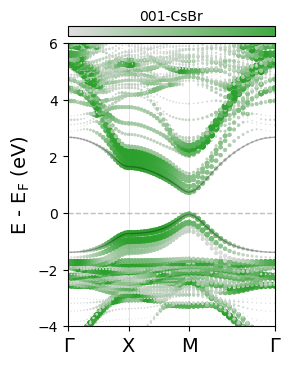

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1. LER PBAND_SUM.dat
# ============================
arquivo_bandas = "soc_bands/PBAND_SUM_SOC_001CsBr.dat"

bandas = {}
k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []

with open(arquivo_bandas, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("#K-Path") or linha.startswith("# NKPTS"):
            continue

        if linha.startswith("# Band-Index:"):
            # salva a banda anterior
            if k_vals and e_vals:
                bandas[band_index] = {
                    "k": np.array(k_vals),
                    "E": np.array(e_vals),
                    "s": np.array(s_vals),
                    "p": np.array(p_vals),
                    "d": np.array(d_vals),
                    "tot": np.array(tot_vals),
                }
                k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []
            band_index = int(linha.split()[-1])
            continue

        partes = linha.split()
        if len(partes) >= 6:
            k_vals.append(float(partes[0]))
            e_vals.append(float(partes[1]))
            s_vals.append(float(partes[2]))
            p_vals.append(float(partes[3]))
            d_vals.append(float(partes[4]))
            tot_vals.append(float(partes[5]))

# Salva a última banda
if k_vals and e_vals:
    bandas[band_index] = {
        "k": np.array(k_vals),
        "E": np.array(e_vals),
        "s": np.array(s_vals),
        "p": np.array(p_vals),
        "d": np.array(d_vals),
        "tot": np.array(tot_vals),
    }

# ============================
# 2. LER KLABELS
# ============================
arquivo_klabels = "KLABELS-001"

k_labels = []
k_positions = []

with open(arquivo_klabels, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("K-Label"):
            continue
        partes = linha.split()
        if len(partes) == 2:
            label, pos = partes
            k_labels.append(label.replace("GAMMA", "Γ"))
            k_positions.append(float(pos))

# ============================
# 3. ESCOLHER ORBITAL
# ============================
# pode ser "s", "p", "d" ou "tot"
orbital = "tot"

# ============================
# 4. PLOTAR
# ============================
plt.figure(figsize=(3,4))

import matplotlib.colors as mcolors

# Cores de início e fim
colors = ["gainsboro", colors_p[2]]

# Criar colormap contínuo azul→vermelho
cmap = mcolors.LinearSegmentedColormap.from_list("azul_vermelho", colors)

for b in bandas:
    data = bandas[b]
    k = data["k"]
    e = data["E"]
    w = data[orbital]

    # Normaliza o tamanho dos marcadores para visualização
    if np.max(w) > 0:
        sizes = 25 * (w / np.max(w))  # escala relativa
    else:
        sizes = np.zeros_like(w)
        
    if b == 186:
        plt.plot(k, e, c="black", linewidth=1, alpha=0.3)
    
    if b == 188:
        plt.plot(k, e, c="black", linewidth=1, alpha=0.3)

    plt.scatter(k, e, s=sizes, c=w, cmap=cmap, alpha=0.9, edgecolors="none")
    

# Linhas verticais nos pontos de alta simetria
for pos in k_positions:
    plt.axvline(pos, color="gray", alpha=0.3, lw=0.5)

plt.axhline(0, color="gray", alpha=0.5, lw=1, linestyle="--")
plt.xticks(k_positions, k_labels, fontsize=14)
plt.ylim(-4, 6)
plt.xlim(k_vals[-1], k_vals[0]+0.0001)
plt.ylabel(r"E - E$_{\mathrm{F}}$ (eV)", fontsize=14)
plt.colorbar(label=f"001-CsBr", location='top', ticks=[], pad=0.02)
plt.tight_layout()
plt.savefig('surf_bands_001-CsBr.png', dpi = 600, bbox_inches="tight")
plt.show()


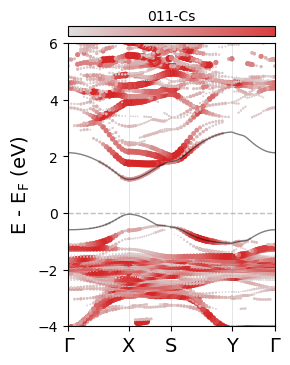

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1. LER PBAND_SUM.dat
# ============================
arquivo_bandas = "soc_bands/PBAND_SUM_SOC_011Cs.dat"

bandas = {}
k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []

with open(arquivo_bandas, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("#K-Path") or linha.startswith("# NKPTS"):
            continue

        if linha.startswith("# Band-Index:"):
            # salva a banda anterior
            if k_vals and e_vals:
                bandas[band_index] = {
                    "k": np.array(k_vals),
                    "E": np.array(e_vals),
                    "s": np.array(s_vals),
                    "p": np.array(p_vals),
                    "d": np.array(d_vals),
                    "tot": np.array(tot_vals),
                }
                k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []
            band_index = int(linha.split()[-1])
            continue

        partes = linha.split()
        if len(partes) >= 6:
            k_vals.append(float(partes[0]))
            e_vals.append(float(partes[1]))
            s_vals.append(float(partes[2]))
            p_vals.append(float(partes[3]))
            d_vals.append(float(partes[4]))
            tot_vals.append(float(partes[5]))

# Salva a última banda
if k_vals and e_vals:
    bandas[band_index] = {
        "k": np.array(k_vals),
        "E": np.array(e_vals),
        "s": np.array(s_vals),
        "p": np.array(p_vals),
        "d": np.array(d_vals),
        "tot": np.array(tot_vals),
    }

# ============================
# 2. LER KLABELS
# ============================
arquivo_klabels = "KLABELS-011"

k_labels = []
k_positions = []

with open(arquivo_klabels, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("K-Label"):
            continue
        partes = linha.split()
        if len(partes) == 2:
            label, pos = partes
            k_labels.append(label.replace("GAMMA", "Γ"))
            k_positions.append(float(pos))

# ============================
# 3. ESCOLHER ORBITAL
# ============================
# pode ser "s", "p", "d" ou "tot"
orbital = "tot"

# ============================
# 4. PLOTAR
# ============================
plt.figure(figsize=(3,4))

import matplotlib.colors as mcolors

# Cores de início e fim
colors = ["gainsboro", colors_p[3]]

# Criar colormap contínuo azul→vermelho
cmap = mcolors.LinearSegmentedColormap.from_list("azul_vermelho", colors)

for b in bandas:
    data = bandas[b]
    k = data["k"]
    e = data["E"]
    w = data[orbital]

    # Normaliza o tamanho dos marcadores para visualização
    if np.max(w) > 0:
        sizes = 25 * (w / np.max(w))  # escala relativa
    else:
        sizes = np.zeros_like(w)
        
    if b == 168:
        plt.plot(k, e, c="black", linewidth=1, alpha=0.5)
    
    if b == 170:
        plt.plot(k, e, c="black", linewidth=1, alpha=0.5)

    plt.scatter(k, e, s=sizes, c=w, cmap=cmap, alpha=0.9, edgecolors="none")
    


# Linhas verticais nos pontos de alta simetria
for pos in k_positions:
    plt.axvline(pos, color="gray", alpha=0.3, lw=0.5)

plt.axhline(0, color="gray", alpha=0.5, lw=1, linestyle="--")
plt.xticks(k_positions, k_labels, fontsize=14)
plt.ylim(-4, 6)
plt.xlim(k_vals[-1], k_vals[0]+0.0001)
plt.ylabel(r"E - E$_{\mathrm{F}}$ (eV)", fontsize=14)
plt.colorbar(label=f"011-Cs", location='top', ticks=[], pad=0.02)
plt.tight_layout()
plt.savefig('surf_bands_011-Cs.png', dpi = 600, bbox_inches="tight")
plt.show()


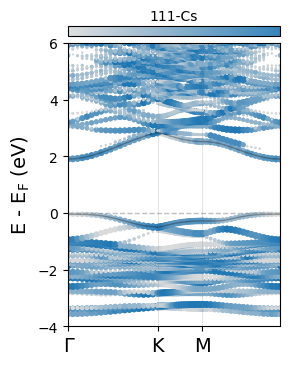

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1. LER PBAND_SUM.dat
# ============================
arquivo_bandas = "soc_bands/PBAND_SUM_SOC_111Cs.dat"

bandas = {}
k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []

with open(arquivo_bandas, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("#K-Path") or linha.startswith("# NKPTS"):
            continue

        if linha.startswith("# Band-Index:"):
            # salva a banda anterior
            if k_vals and e_vals:
                bandas[band_index] = {
                    "k": np.array(k_vals),
                    "E": np.array(e_vals),
                    "s": np.array(s_vals),
                    "p": np.array(p_vals),
                    "d": np.array(d_vals),
                    "tot": np.array(tot_vals),
                }
                k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []
            band_index = int(linha.split()[-1])
            continue

        partes = linha.split()
        if len(partes) >= 6:
            k_vals.append(float(partes[0]))
            e_vals.append(float(partes[1]))
            s_vals.append(float(partes[2]))
            p_vals.append(float(partes[3]))
            d_vals.append(float(partes[4]))
            tot_vals.append(float(partes[5]))

# Salva a última banda
if k_vals and e_vals:
    bandas[band_index] = {
        "k": np.array(k_vals),
        "E": np.array(e_vals),
        "s": np.array(s_vals),
        "p": np.array(p_vals),
        "d": np.array(d_vals),
        "tot": np.array(tot_vals),
    }

# ============================
# 2. LER KLABELS
# ============================
arquivo_klabels = "KLABELS-111"

k_labels = []
k_positions = []

with open(arquivo_klabels, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("K-Label"):
            continue
        partes = linha.split()
        if len(partes) == 2:
            label, pos = partes
            k_labels.append(label.replace("GAMMA", "Γ"))
            k_positions.append(float(pos))

# ============================
# 3. ESCOLHER ORBITAL
# ============================
# pode ser "s", "p", "d" ou "tot"
orbital = "tot"

# ============================
# 4. PLOTAR
# ============================
plt.figure(figsize=(3,4))

import matplotlib.colors as mcolors

# Cores de início e fim
colors = ["gainsboro", colors_p[0]]

# Criar colormap contínuo azul→vermelho
cmap = mcolors.LinearSegmentedColormap.from_list("azul_vermelho", colors)

for b in bandas:
    data = bandas[b]
    k = data["k"]
    e = data["E"]
    w = data[orbital]

    # Normaliza o tamanho dos marcadores para visualização
    if np.max(w) > 0:
        sizes = 25 * (w / np.max(w))  # escala relativa
    else:
        sizes = np.zeros_like(w)
        
    if b == 150:
        plt.plot(k, e, c="black", linewidth=1, alpha=0.3)
    
    if b == 152:
        plt.plot(k, e, c="black", linewidth=1, alpha=0.3)

    plt.scatter(k, e, s=sizes, c=w, cmap=cmap, alpha=0.9, edgecolors="none")
    


# Linhas verticais nos pontos de alta simetria
for pos in k_positions:
    plt.axvline(pos, color="gray", alpha=0.3, lw=0.5)

plt.axhline(0, color="gray", alpha=0.5, lw=1, linestyle="--")
plt.xticks(k_positions, k_labels, fontsize=14)
plt.ylim(-4, 6)
plt.xlim(k_vals[-1], k_vals[0]+0.0001)
plt.ylabel(r"E - E$_{\mathrm{F}}$ (eV)", fontsize=14)
plt.colorbar(label=f"111-Cs", location='top', ticks=[], pad=0.02)
plt.tight_layout()
plt.savefig('surf_bands_111-Cs.png', dpi = 600, bbox_inches="tight")
plt.show()


In [107]:
(1/2)*((2*np.pi)/(5.8583407238771175))

0.5362598048941494

### SOC

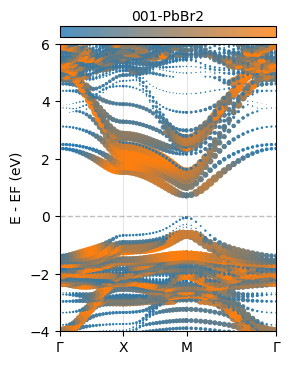

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1. LER PBAND_SUM.dat
# ============================
arquivo_bandas = "PBAND_SUM_SOC.dat"

bandas = {}
k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []

with open(arquivo_bandas, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("#K-Path") or linha.startswith("# NKPTS"):
            continue

        if linha.startswith("# Band-Index:"):
            # salva a banda anterior
            if k_vals and e_vals:
                bandas[band_index] = {
                    "k": np.array(k_vals),
                    "E": np.array(e_vals),
                    "s": np.array(s_vals),
                    "p": np.array(p_vals),
                    "d": np.array(d_vals),
                    "tot": np.array(tot_vals),
                }
                k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []
            band_index = int(linha.split()[-1])
            continue

        partes = linha.split()
        if len(partes) >= 6:
            k_vals.append(float(partes[0]))
            e_vals.append(float(partes[1]))
            s_vals.append(float(partes[2]))
            p_vals.append(float(partes[3]))
            d_vals.append(float(partes[4]))
            tot_vals.append(float(partes[5]))

# Salva a última banda
if k_vals and e_vals:
    bandas[band_index] = {
        "k": np.array(k_vals),
        "E": np.array(e_vals),
        "s": np.array(s_vals),
        "p": np.array(p_vals),
        "d": np.array(d_vals),
        "tot": np.array(tot_vals),
    }

# ============================
# 2. LER KLABELS
# ============================
arquivo_klabels = "KLABELS-001"

k_labels = []
k_positions = []

with open(arquivo_klabels, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("K-Label"):
            continue
        partes = linha.split()
        if len(partes) == 2:
            label, pos = partes
            k_labels.append(label.replace("GAMMA", "Γ"))
            k_positions.append(float(pos))

# ============================
# 3. ESCOLHER ORBITAL
# ============================
# pode ser "s", "p", "d" ou "tot"
orbital = "tot"

# ============================
# 4. PLOTAR
# ============================
plt.figure(figsize=(3,4))

import matplotlib.colors as mcolors

# Cores de início e fim
colors = [colors_p[0], colors_p[1]]

# Criar colormap contínuo azul→vermelho
cmap = mcolors.LinearSegmentedColormap.from_list("azul_vermelho", colors)

for b in bandas:
    data = bandas[b]
    k = data["k"]
    e = data["E"]
    w = data[orbital]

    max_abs = np.max(np.abs(w))

    if max_abs > 0:
        sizes = 50 * (np.abs(w) / max_abs)
    else:
        sizes = np.zeros_like(w)

    plt.scatter(k, e, s=sizes, c=w, cmap=cmap, alpha=0.8, edgecolors="none")

# Linhas verticais nos pontos de alta simetria
for pos in k_positions:
    plt.axvline(pos, color="gray", alpha=0.3, lw=0.5)

plt.axhline(0, color="gray", alpha=0.5, lw=1, linestyle="--")
plt.xticks(k_positions, k_labels)
plt.ylim(-4, 6)
plt.xlim(k_vals[-1], k_vals[0]+0.0001)
plt.ylabel("E - EF (eV)")
plt.colorbar(label=f"001-PbBr2", location='top', ticks=[], pad=0.02)
plt.tight_layout()
plt.savefig('surf_bands_001-PbBr2.png', dpi = 600, bbox_inches="tight")
plt.show()


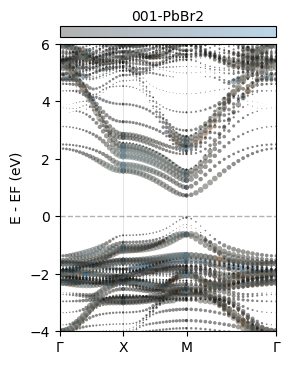

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1. LER PBAND_SUM.dat
# ============================
arquivo_bandas = "PBAND_SUM_SOC.dat"

bandas = {}
k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []

with open(arquivo_bandas, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("#K-Path") or linha.startswith("# NKPTS"):
            continue

        if linha.startswith("# Band-Index:"):
            # salva a banda anterior
            if k_vals and e_vals:
                bandas[band_index] = {
                    "k": np.array(k_vals),
                    "E": np.array(e_vals),
                    "s": np.array(s_vals),
                    "p": np.array(p_vals),
                    "d": np.array(d_vals),
                    "tot": np.array(tot_vals),
                }
                k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []
            band_index = int(linha.split()[-1])
            continue

        partes = linha.split()
        if len(partes) >= 6:
            k_vals.append(float(partes[0]))
            e_vals.append(float(partes[1]))
            s_vals.append(float(partes[2]))
            p_vals.append(float(partes[3]))
            d_vals.append(float(partes[4]))
            tot_vals.append(float(partes[5]))

# Salva a última banda
if k_vals and e_vals:
    bandas[band_index] = {
        "k": np.array(k_vals),
        "E": np.array(e_vals),
        "s": np.array(s_vals),
        "p": np.array(p_vals),
        "d": np.array(d_vals),
        "tot": np.array(tot_vals),
    }

# ============================
# 2. LER KLABELS
# ============================
arquivo_klabels = "KLABELS-001"

k_labels = []
k_positions = []

with open(arquivo_klabels, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("K-Label"):
            continue
        partes = linha.split()
        if len(partes) == 2:
            label, pos = partes
            k_labels.append(label.replace("GAMMA", "Γ"))
            k_positions.append(float(pos))

# ============================
# 3. ESCOLHER ORBITAL
# ============================
# pode ser "s", "p", "d" ou "tot"
orbital = "tot"

# ============================
# 4. PLOTAR
# ============================
plt.figure(figsize=(3,4))

import matplotlib.colors as mcolors

# Cores de início e fim
colors1 = ["black", colors_p[1]]

# Criar colormap contínuo azul→vermelho
cmap1 = mcolors.LinearSegmentedColormap.from_list("azul_vermelho", colors1)

# Cores de início e fim
colors2 = ["black", colors_p[0]]

# Criar colormap contínuo azul→vermelho
cmap2 = mcolors.LinearSegmentedColormap.from_list("azul_vermelho", colors2)

cmap = [cmap1, cmap2]

i_bands = 0

for b in bandas:
    data = bandas[b]
    k = data["k"]
    e = data["E"]
    w = data[orbital]
    idx_color = i_bands % 2

    # Normaliza o tamanho dos marcadores para visualização
    if np.max(w) > 0:
        sizes = 25 * (w / np.max(w))  # escala relativa
    else:
        sizes = np.zeros_like(w)

    
    plt.scatter(k, e, s=sizes, c=w, cmap=cmap[idx_color], alpha=0.3, edgecolors="none")
    
    i_bands +=1

# Linhas verticais nos pontos de alta simetria
for pos in k_positions:
    plt.axvline(pos, color="gray", alpha=0.3, lw=0.5)

plt.axhline(0, color="gray", alpha=0.6, lw=1, linestyle="--")
plt.xticks(k_positions, k_labels)
plt.ylim(-4, 6)
plt.xlim(k_vals[-1], k_vals[0]+0.0001)
plt.ylabel("E - EF (eV)")
plt.colorbar(label=f"001-PbBr2", location='top', ticks=[], pad=0.02)
plt.tight_layout()
plt.savefig('surf_bands_001-PbBr2.png', dpi = 600, bbox_inches="tight")
plt.show()


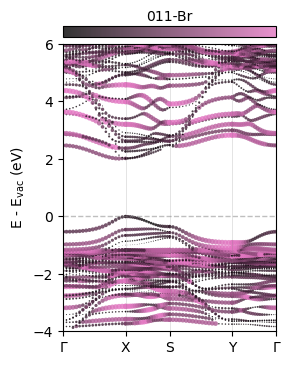

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1. LER PBAND_SUM.dat
# ============================
arquivo_bandas = "011Br-PBAND_SUM.dat"

bandas = {}
k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []

with open(arquivo_bandas, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("#K-Path") or linha.startswith("# NKPTS"):
            continue

        if linha.startswith("# Band-Index:"):
            # salva a banda anterior
            if k_vals and e_vals:
                bandas[band_index] = {
                    "k": np.array(k_vals),
                    "E": np.array(e_vals),
                    "s": np.array(s_vals),
                    "p": np.array(p_vals),
                    "d": np.array(d_vals),
                    "tot": np.array(tot_vals),
                }
                k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []
            band_index = int(linha.split()[-1])
            continue

        partes = linha.split()
        if len(partes) >= 6:
            k_vals.append(float(partes[0]))
            e_vals.append(float(partes[1]))
            s_vals.append(float(partes[2]))
            p_vals.append(float(partes[3]))
            d_vals.append(float(partes[4]))
            tot_vals.append(float(partes[5]))

# Salva a última banda
if k_vals and e_vals:
    bandas[band_index] = {
        "k": np.array(k_vals),
        "E": np.array(e_vals),
        "s": np.array(s_vals),
        "p": np.array(p_vals),
        "d": np.array(d_vals),
        "tot": np.array(tot_vals),
    }

# ============================
# 2. LER KLABELS
# ============================
arquivo_klabels = "KLABELS-011"

k_labels = []
k_positions = []

with open(arquivo_klabels, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("K-Label"):
            continue
        partes = linha.split()
        if len(partes) == 2:
            label, pos = partes
            k_labels.append(label.replace("GAMMA", "Γ"))
            k_positions.append(float(pos))

# ============================
# 3. ESCOLHER ORBITAL
# ============================
# pode ser "s", "p", "d" ou "tot"
orbital = "tot"

# ============================
# 4. PLOTAR
# ============================
plt.figure(figsize=(3,4))

import matplotlib.colors as mcolors

# Cores de início e fim
colors = ["black", colors_p[6]]

# Criar colormap contínuo azul→vermelho
cmap = mcolors.LinearSegmentedColormap.from_list("azul_vermelho", colors)

for b in bandas:
    data = bandas[b]
    k = data["k"]
    e = data["E"]
    w = data[orbital]

    # Normaliza o tamanho dos marcadores para visualização
    if np.max(w) > 0:
        sizes = 15 * (w / np.max(w))  # escala relativa
    else:
        sizes = np.zeros_like(w)

    plt.scatter(k, e, s=sizes, c=w, cmap=cmap, alpha=0.8, edgecolors="none")

# Linhas verticais nos pontos de alta simetria
for pos in k_positions:
    plt.axvline(pos, color="gray", alpha=0.3, lw=0.5)

plt.axhline(0, color="gray", alpha=0.5, lw=1, linestyle="--")
plt.xticks(k_positions, k_labels)
plt.ylim(-4, 6)
plt.xlim(k_vals[-1], k_vals[0]+0.0001)
plt.ylabel(r"E - E$_{\mathrm{vac}}$ (eV)")
plt.colorbar(label=f"011-Br", location='top', ticks=[], pad=0.02)
plt.tight_layout()
plt.savefig('surf_bands_011-Br.png', dpi = 600, bbox_inches="tight")
plt.show()


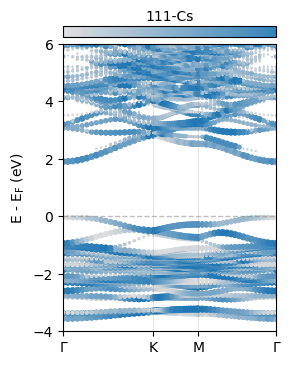

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1. LER PBAND_SUM.dat
# ============================
arquivo_bandas = "soc_bands/PBAND_SUM_SOC_111Cs.dat"

bandas = {}
k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []

with open(arquivo_bandas, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("#K-Path") or linha.startswith("# NKPTS"):
            continue

        if linha.startswith("# Band-Index:"):
            # salva a banda anterior
            if k_vals and e_vals:
                bandas[band_index] = {
                    "k": np.array(k_vals),
                    "E": np.array(e_vals),
                    "s": np.array(s_vals),
                    "p": np.array(p_vals),
                    "d": np.array(d_vals),
                    "tot": np.array(tot_vals),
                }
                k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []
            band_index = int(linha.split()[-1])
            continue

        partes = linha.split()
        if len(partes) >= 6:
            k_vals.append(float(partes[0]))
            e_vals.append(float(partes[1]))
            s_vals.append(float(partes[2]))
            p_vals.append(float(partes[3]))
            d_vals.append(float(partes[4]))
            tot_vals.append(float(partes[5]))

# Salva a última banda
if k_vals and e_vals:
    bandas[band_index] = {
        "k": np.array(k_vals),
        "E": np.array(e_vals),
        "s": np.array(s_vals),
        "p": np.array(p_vals),
        "d": np.array(d_vals),
        "tot": np.array(tot_vals),
    }

# ============================
# 2. LER KLABELS
# ============================
arquivo_klabels = "KLABELS-111"

k_labels = []
k_positions = []

with open(arquivo_klabels, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("K-Label"):
            continue
        partes = linha.split()
        if len(partes) == 2:
            label, pos = partes
            k_labels.append(label.replace("GAMMA", "Γ"))
            k_positions.append(float(pos))

# ============================
# 3. ESCOLHER ORBITAL
# ============================
# pode ser "s", "p", "d" ou "tot"
orbital = "tot"

# ============================
# 4. PLOTAR
# ============================
plt.figure(figsize=(3,4))

import matplotlib.colors as mcolors

# Cores de início e fim
colors = ["gainsboro", colors_p[10]]

# Criar colormap contínuo azul→vermelho
cmap = mcolors.LinearSegmentedColormap.from_list("azul_vermelho", colors)

for b in bandas:
    data = bandas[b]
    k = data["k"]
    e = data["E"]
    w = data[orbital]

    # Normaliza o tamanho dos marcadores para visualização
    if np.max(w) > 0:
        sizes = 25 * (w / np.max(w))  # escala relativa
    else:
        sizes = np.zeros_like(w)

    plt.scatter(k, e, s=sizes, c=w, cmap=cmap, alpha=0.9, edgecolors="none")
    
#    if b == 178:
#        plt.plot(k, e, c="black", linewidth=1)
#    
#    if b == 180:
#        plt.plot(k, e, c="black", linewidth=1)

# Linhas verticais nos pontos de alta simetria
for pos in k_positions:
    plt.axvline(pos, color="gray", alpha=0.3, lw=0.5)

plt.axhline(0, color="gray", alpha=0.5, lw=1, linestyle="--")
plt.xticks(k_positions, k_labels)
plt.ylim(-4, 6)
plt.xlim(k_vals[-1]-0.0001, k_vals[0]-0.0001)
plt.ylabel(r"E - E$_{\mathrm{F}}$ (eV)")
plt.colorbar(label=r"111-Cs", location='top', ticks=[], pad=0.02)
plt.tight_layout()
plt.savefig('surf_bands_111-Cs.png', dpi = 600, bbox_inches="tight")
plt.show()


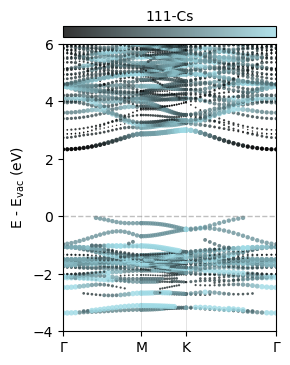

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1. LER PBAND_SUM.dat
# ============================
arquivo_bandas = "111Cs-PBAND_SUM.dat"

bandas = {}
k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []

with open(arquivo_bandas, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("#K-Path") or linha.startswith("# NKPTS"):
            continue

        if linha.startswith("# Band-Index:"):
            # salva a banda anterior
            if k_vals and e_vals:
                bandas[band_index] = {
                    "k": np.array(k_vals),
                    "E": np.array(e_vals),
                    "s": np.array(s_vals),
                    "p": np.array(p_vals),
                    "d": np.array(d_vals),
                    "tot": np.array(tot_vals),
                }
                k_vals, e_vals, s_vals, p_vals, d_vals, tot_vals = [], [], [], [], [], []
            band_index = int(linha.split()[-1])
            continue

        partes = linha.split()
        if len(partes) >= 6:
            k_vals.append(float(partes[0]))
            e_vals.append(float(partes[1]))
            s_vals.append(float(partes[2]))
            p_vals.append(float(partes[3]))
            d_vals.append(float(partes[4]))
            tot_vals.append(float(partes[5]))

# Salva a última banda
if k_vals and e_vals:
    bandas[band_index] = {
        "k": np.array(k_vals),
        "E": np.array(e_vals),
        "s": np.array(s_vals),
        "p": np.array(p_vals),
        "d": np.array(d_vals),
        "tot": np.array(tot_vals),
    }

# ============================
# 2. LER KLABELS
# ============================
arquivo_klabels = "KLABELS-111"

k_labels = []
k_positions = []

with open(arquivo_klabels, "r") as f:
    for linha in f:
        linha = linha.strip()
        if not linha or linha.startswith("K-Label"):
            continue
        partes = linha.split()
        if len(partes) == 2:
            label, pos = partes
            k_labels.append(label.replace("GAMMA", "Γ"))
            k_positions.append(float(pos))

# ============================
# 3. ESCOLHER ORBITAL
# ============================
# pode ser "s", "p", "d" ou "tot"
orbital = "tot"

# ============================
# 4. PLOTAR
# ============================
plt.figure(figsize=(3,4))

import matplotlib.colors as mcolors

# Cores de início e fim
colors = ["black", colors_p[10]]

# Criar colormap contínuo azul→vermelho
cmap = mcolors.LinearSegmentedColormap.from_list("azul_vermelho", colors)

for b in bandas:
    data = bandas[b]
    k = data["k"]
    e = data["E"]
    w = data[orbital]

    # Normaliza o tamanho dos marcadores para visualização
    if np.max(w) > 0:
        sizes = 15 * (w / np.max(w))  # escala relativa
    else:
        sizes = np.zeros_like(w)

    plt.scatter(k, e, s=sizes, c=w, cmap=cmap, alpha=0.8, edgecolors="none")

# Linhas verticais nos pontos de alta simetria
for pos in k_positions:
    plt.axvline(pos, color="gray", alpha=0.3, lw=0.5)

plt.axhline(0, color="gray", alpha=0.5, lw=1, linestyle="--")
plt.xticks(k_positions, k_labels)
plt.ylim(-4, 6)
plt.xlim(k_vals[-1], k_vals[0]+0.0001)
plt.ylabel(r"E - E$_{\mathrm{vac}}$ (eV)")
plt.colorbar(label=f"111-Cs", location='top', ticks=[], pad=0.02)
plt.tight_layout()
plt.savefig('surf_bands_111-Cs.png', dpi = 600, bbox_inches="tight")
plt.show()


In [84]:
E_core_bulk = -21.630022
E_core_001 = -21.603097
E_core_001_0 = -21.278380
E_core_011 = -21.471053
E_core_111 = -21.783824

E_VBM_bulk = 1.1326
E_VBM_001 = -1.4756
E_VBM_001_0 = -1.7782
E_VBM_011 = -1.6036
E_VBM_111 = -1.4955

E_CBM_bulk = -1.5942
E_CBM_001_0 = -1.0106
E_CBM_001 = -0.6960
E_CBM_011 = -0.3756
E_CBM_111 = 0.4537

In [85]:
E_core = np.array([E_core_bulk, E_core_001, E_core_001_0, E_core_011, E_core_111])
E_VBM = np.array([E_VBM_bulk, E_VBM_001, E_VBM_001_0, E_VBM_011, E_VBM_111])
E_CBM = np.array([E_CBM_bulk, E_CBM_001, E_CBM_001_0, E_CBM_011, E_CBM_111])
E_VBM = E_VBM - E_core
E_CBM = E_CBM - E_core

E_CBM = E_CBM - E_VBM[0]
E_VBM = E_VBM - E_VBM[0]

In [86]:
E_VBM = E_VBM - E_core
E_CBM = E_CBM - E_core

E_CBM = E_CBM - E_VBM[0]
E_VBM = E_VBM - E_VBM[0]

In [87]:
np.round(E_VBM,2)

array([ 0.  , -2.66, -3.61, -3.05, -2.32])

In [88]:
np.round(E_CBM,2)

array([-2.73, -1.88, -2.85, -1.83, -0.37])